# M2: HC vs. PD, and the DC offset

`PLANScores.md` M2: HC vs PD error profiles side by side, the same per-feature comparison battery as `02_group_comparisons.ipynb` filtered to this pair, and a quantified answer to "PD looks like HC + a number": `comparisons.estimate_offset` fits the single additive constant `c` that best predicts PD's mean profile from HC's (`PD ~= HC + c`), bootstraps *subjects* for its CI/p-value (not cap positions -- see the function's docstring for why that distinction matters), and reports an R2 for how much of PD's own cap-to-cap shape that single constant explains.

In [1]:
import sys
sys.path.append('../scripts')

import matplotlib.pyplot as plt

import comparisons
import loader
import plotting

df = loader.load_fm100_raw()
categories = [{'label': 'HC', 'group': 'CTR'}, {'label': 'PD', 'group': 'PD'}]

## Profiles side by side

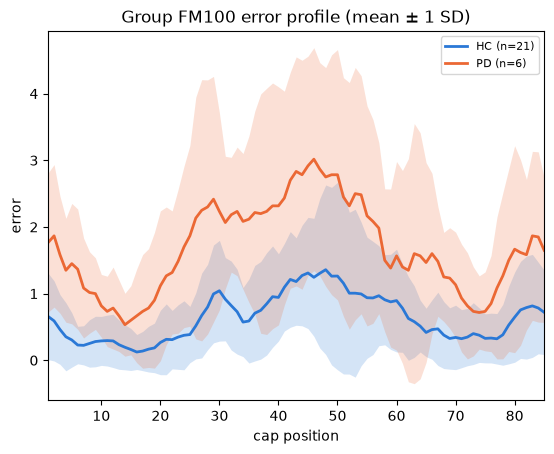

In [3]:
plotting.plot_group_fm100(df, categories, kind='linear',window=5);

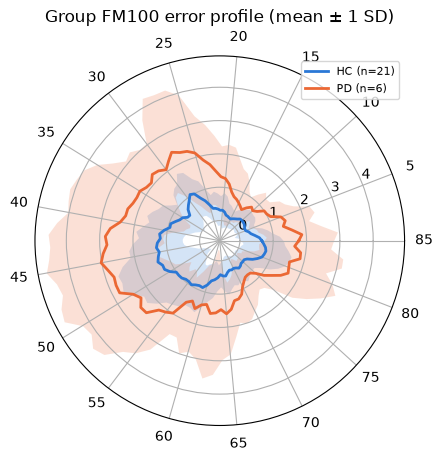

In [4]:
plotting.plot_group_fm100(df, categories, kind='radial', label_mode='cap', window=5);

## Per-feature comparison

In [9]:
import pandas as pd
pd.DataFrame([comparisons.compare_fm100_feature(df, f, group1='CTR', group2='PD') for f in comparisons.FEATURES])

,feature,u_val,p_value,rbc,cles,n1,n2
0,TES,21.5,0.016728,-0.658730,0.170635,21,6
1,PES_RG,17.5,0.008648,-0.722222,0.138889,21,6
2,PES_BY,22.0,0.018159,-0.650794,0.174603,21,6
3,VKS_MajRad,23.0,0.018148,-0.634921,0.182540,21,6
4,VKS_MinRad,20.0,0.010223,-0.682540,0.158730,21,6
5,VKS_Angle,59.0,0.842472,-0.063492,0.468254,21,6


## The DC offset: does 'PD = HC + c' hold?

In [6]:
hc_profiles = plotting.group_profiles(df, group='CTR',window=5)
pd_profiles = plotting.group_profiles(df, group='PD',window=5)
offset_result = comparisons.estimate_offset(hc_profiles, pd_profiles, n_boot=2000, seed=0)
offset_result

{'offset': 1.0444444444444445,
 'ci_lower': 0.3164752567693744,
 'ci_upper': 1.8069514472455652,
 'p_value': 0.0029985007496251873,
 'r_squared': 0.6656243531028772}

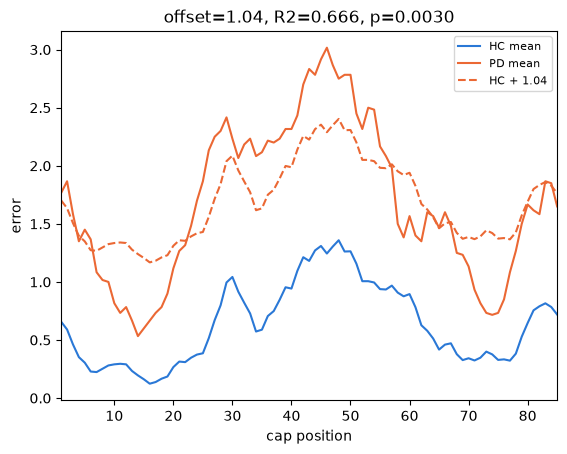

In [7]:
hc_mean, pd_mean = hc_profiles.mean(axis=0), pd_profiles.mean(axis=0)
fig, ax = plt.subplots()
ax.plot(plotting.CAP_POSITIONS, hc_mean, label='HC mean', color=plotting.FULL_PALETTE[0])
ax.plot(plotting.CAP_POSITIONS, pd_mean, label='PD mean', color=plotting.FULL_PALETTE[1])
ax.plot(plotting.CAP_POSITIONS, hc_mean + offset_result['offset'], label=f"HC + {offset_result['offset']:.2f}", color=plotting.FULL_PALETTE[1], linestyle='--')
ax.set_xlim(1, 85)
ax.set_xlabel('cap position')
ax.set_ylabel('error')
ax.set_title(f"offset={offset_result['offset']:.2f}, R2={offset_result['r_squared']:.3f}, p={offset_result['p_value']:.4f}")
ax.legend(fontsize=8);